
## Getting Started

1. Create a new Jupyter Notebook called **`m4-01-fundamentals-feature-engineering.ipynb`**.
2. Start with an import cell:

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
```

3. Work through the tasks in order. Each task builds on the previous one.
4. Include markdown cells between code cells to explain your observations and reasoning.

## Tasks

### Task 1: Data Exploration

Load the Titanic dataset from seaborn and get familiar with its structure.

```python
titanic = sns.load_dataset("titanic")
```

1. Display the first few rows and inspect the shape of the dataset.
2. Check data types for each column. Which are numerical? Which are categorical?
3. Identify missing values — which columns have them, and what percentage of values are missing?
4. Examine the class balance of the target variable (`survived`). What is the survival rate?
5. Create at least two visualizations: one showing the distribution of a numerical feature (e.g., `age`) and one showing survival rates broken down by a categorical feature (e.g., `pclass` or `sex`).

Write a brief summary of your findings in a markdown cell.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

In [11]:
titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
titanic.shape

(891, 15)

In [13]:
titanic.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [14]:
missing_counts = titanic.isnull().sum()
missing_percent = (missing_counts / len(titanic)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467
class,0,0.000000
who,0,0.000000


In [16]:
titanic["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [21]:
titanic["survived"].value_counts(normalize=True) * 100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

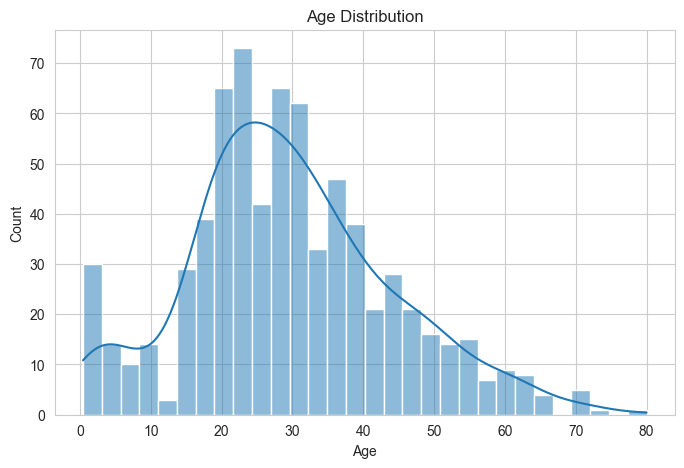

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(titanic["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

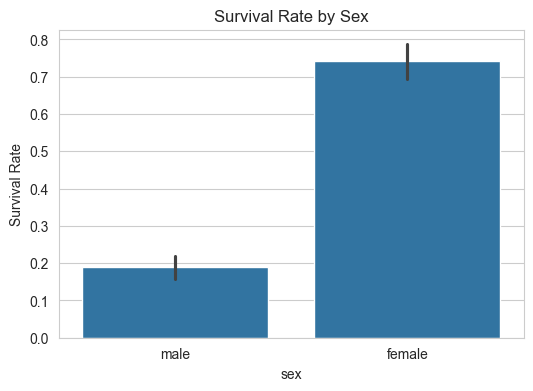

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x="sex", y="survived", data=titanic)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

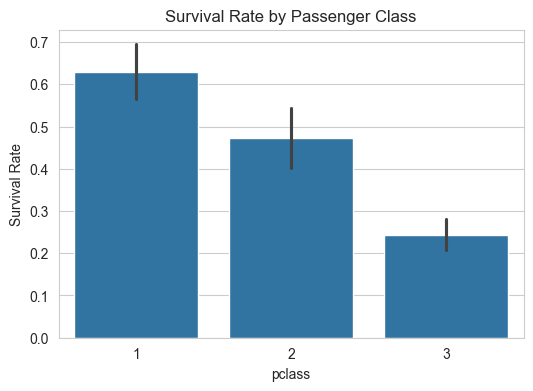

In [20]:
plt.figure(figsize=(6,4))
sns.barplot(x="pclass", y="survived", data=titanic)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

### Markdown

The Titanic dataset contains 891 rows and 15 columns, including a mix of numerical, categorical, and boolean features. From the data types, we can understand that features like age, fare, sibsp, parch, and pclass are numerical, while columns such as sex, embarked, class, who, embark_town, and alive are categorical. In addition, there are boolean features like adult_male and alone.

When analyzing missing values, we see that the age column has around 20% missing data, which is quite significant and will need to be handled. The deck column has an even higher percentage of missing values, about 77%, making it mostly unusable for analysis. On the other hand, embarked and embark_town have only a very small number of missing values, so they can be handled easily.

It is also noticeable that some features are duplicated or provide very similar information. For example, class is essentially the same as pclass, alive duplicates the survived column, and embark_town is just a more descriptive version of embarked. These columns may not all be necessary for modeling.

Looking at the target variable, we observe that approximately 61% of passengers did not survive, while about 39% survived. This indicates a slight imbalance in the dataset. Based on the visualizations, features such as sex and pclass seem to have a strong relationship with survival, suggesting that they will likely be important predictors in our model.

### Task 2: Feature Engineering

Transform the raw features into a format suitable for machine learning.

1. **Handle missing values:**
   - Fill missing `age` values with the median age.
   - Fill missing `embarked` values with the mode (most frequent value).
   - Drop the `deck` column (too many missing values to be useful).

2. **Encode categorical features:**
   - Apply label encoding to `sex` (male → 1, female → 0).
   - Apply one-hot encoding to `embarked` (creating dummy columns).

3. **Create new features:**
   - `family_size` = `sibsp` + `parch` + 1 (the passenger plus their siblings/spouses and parents/children).
   - `is_alone` = 1 if `family_size` == 1, else 0.

4. Drop non-numeric and identifier columns that won't be useful for modeling (e.g., `alive`, `who`, `adult_male`, `embark_town`, `class`, `alone`).

5. Display the final DataFrame and confirm all columns are numeric.


In [22]:
df = titanic.copy()
df["age"] = df["age"].fillna(df["age"].median())

df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df = df.drop(columns=["deck"])

df["sex"] = df["sex"].map({"male": 1, "female": 0})

df = pd.get_dummies(df, columns=["embarked"], drop_first=True)

df["family_size"] = df["sibsp"] + df["parch"] + 1

df["is_alone"] = (df["family_size"] == 1).astype(int)

df = df.drop(columns=[
    "alive",
    "who",
    "adult_male",
    "embark_town",
    "class",
    "alone"
])

In [24]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,False,True,2,0
1,1,1,0,38.0,1,0,71.2833,False,False,2,0
2,1,3,0,26.0,0,0,7.9250,False,True,1,1
3,1,1,0,35.0,1,0,53.1000,False,True,2,0
4,0,3,1,35.0,0,0,8.0500,False,True,1,1


In [25]:
df.dtypes

survived         int64
pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare           float64
embarked_Q        bool
embarked_S        bool
family_size      int64
is_alone         int64
dtype: object

### Markdown
We handled missing values by filling the age column with the median value and the embarked column with the most frequent value (mode). This helps us avoid losing data while keeping the distribution reasonable.

We dropped the deck column because it contains a very high percentage of missing values (around 80%), which makes it unreliable and not useful for building a machine learning model.

In addition, we removed some unnecessary columns such as alive, class, and embark_town because they either duplicate information from other features or do not add meaningful value to the model. This helps simplify the dataset and keep only the most relevant features.

### Task 3: Feature Scaling & Selection

Apply scaling techniques and identify the most relevant features.

1. **Compare scalers:** Apply both `StandardScaler` and `MinMaxScaler` to the numeric features. Plot the distributions of `age` and `fare` before and after each scaling method (use histograms or KDE plots). In a markdown cell, explain the difference between the two approaches.

2. **Correlation analysis:** Compute the correlation matrix for all numeric features. Plot it as a heatmap with annotations. Which features have the strongest positive and negative correlations with `survived`?

3. **Feature selection:** Based on the correlation matrix, select the top features most correlated with the target (absolute correlation ≥ 0.1). List them and briefly justify keeping or dropping borderline features.


In [27]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,family_size,is_alone
0,0,3,1,22.0,1,0,7.2500,2,0
1,1,1,0,38.0,1,0,71.2833,2,0
2,1,3,0,26.0,0,0,7.9250,1,1
3,1,1,0,35.0,1,0,53.1000,2,0
4,0,3,1,35.0,0,0,8.0500,1,1


In [28]:
scaler_standard = StandardScaler()
df_standard = pd.DataFrame(
    scaler_standard.fit_transform(numeric_df),
    columns=numeric_df.columns
)

In [29]:
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(numeric_df),
    columns=numeric_df.columns
)

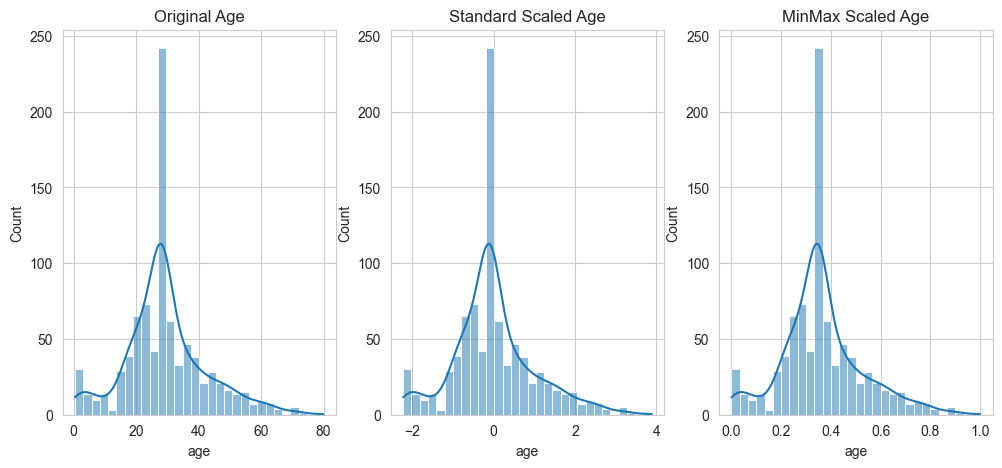

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.histplot(numeric_df["age"], kde=True)
plt.title("Original Age")

plt.subplot(1,3,2)
sns.histplot(df_standard["age"], kde=True)
plt.title("Standard Scaled Age")

plt.subplot(1,3,3)
sns.histplot(df_minmax["age"], kde=True)
plt.title("MinMax Scaled Age")

plt.show()

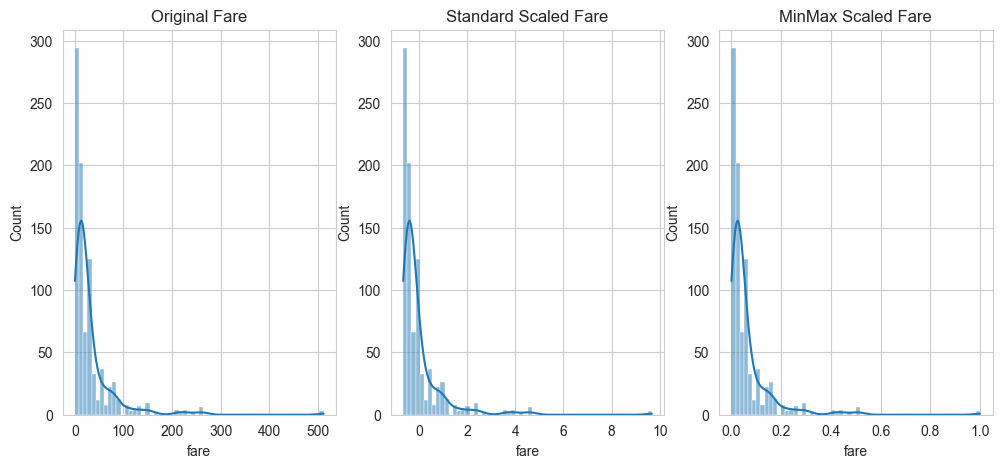

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
sns.histplot(numeric_df["fare"], kde=True)
plt.title("Original Fare")

plt.subplot(1,3,2)
sns.histplot(df_standard["fare"], kde=True)
plt.title("Standard Scaled Fare")

plt.subplot(1,3,3)
sns.histplot(df_minmax["fare"], kde=True)
plt.title("MinMax Scaled Fare")

plt.show()

### Differences between MinMaxScaler and StandardScaler

We can observe that both StandardScaler and MinMaxScaler preserve the overall distribution shape of features like age and fare. The main difference between them is the scaling range.

StandardScaler transforms the data so that it has a mean of 0 and a standard deviation of 1, which results in values that can range from negative to positive (for example, roughly between -2 and 4 for age in this case).

On the other hand, MinMaxScaler scales all values into a fixed range between 0 and 1. This makes all features bounded within the same interval, which can be useful for algorithms that are sensitive to feature magnitude.

In summary, StandardScaler keeps the distribution centered and standardized, while MinMaxScaler compresses all values into a uniform range without changing the shape of the distribution.

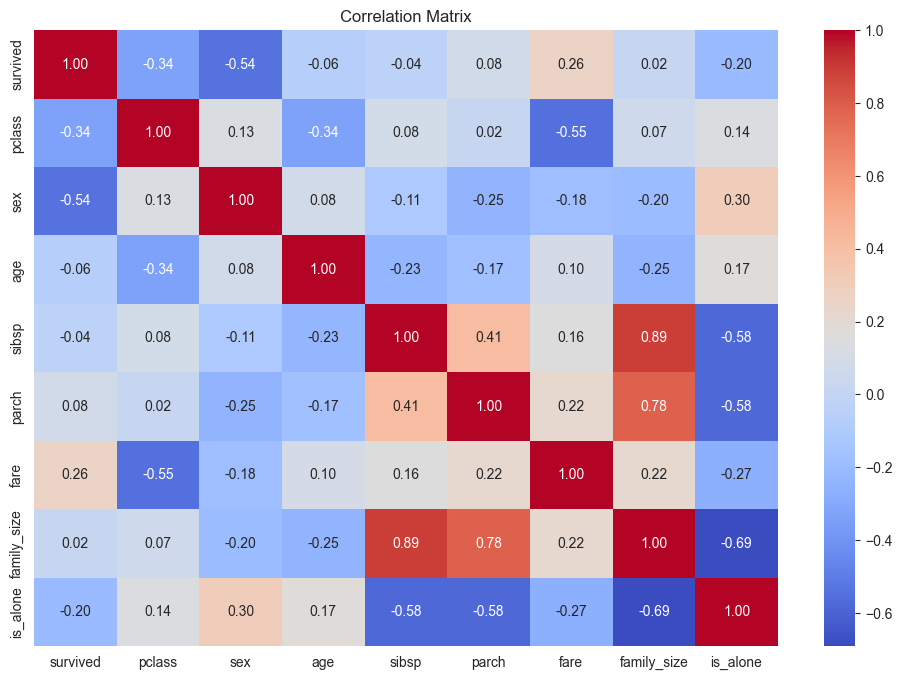

In [33]:
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [36]:
corr_with_target = corr_matrix["survived"].sort_values(ascending=False)
corr_with_target

survived       1.000000
fare           0.257307
parch          0.081629
family_size    0.016639
sibsp         -0.035322
age           -0.064910
is_alone      -0.203367
pclass        -0.338481
sex           -0.543351
Name: survived, dtype: float64

In [37]:
selected_features = corr_with_target[abs(corr_with_target) >= 0.1]
selected_features

survived    1.000000
fare        0.257307
is_alone   -0.203367
pclass     -0.338481
sex        -0.543351
Name: survived, dtype: float64

### Overall correlation

From the correlation analysis, we can observe that fare has the strongest positive correlation with the target variable (survived). This suggests that passengers who paid higher fares had a higher chance of survival.

On the other hand, sex shows the strongest negative correlation with survival, indicating that being male significantly decreases the likelihood of survival compared to females.

We can also see that pclass and is_alone have moderate negative correlations with survival, meaning that passengers in lower classes and those traveling alone were less likely to survive.

Overall, fare, sex, and pclass appear to be the most influential features in predicting survival.

### Task 4: Dimensionality Reduction

Apply PCA to explore the dataset in reduced dimensions.

1. Standardize all numeric features (use `StandardScaler` — PCA requires standardized data).
2. Fit PCA with all components. Plot the **explained variance ratio** for each component as a bar chart, and plot the **cumulative explained variance** as a line chart. How many components do you need to capture at least 80% of the variance?
3. Refit PCA with 2 components. Create a scatter plot of the first two principal components, colored by `survived`. Can you see any separation between survivors and non-survivors?
4. In a markdown cell, discuss: Does PCA help separate the classes? Would you use PCA as a preprocessing step for this dataset, or is the original feature space sufficient?


In [39]:
numeric_df = df.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

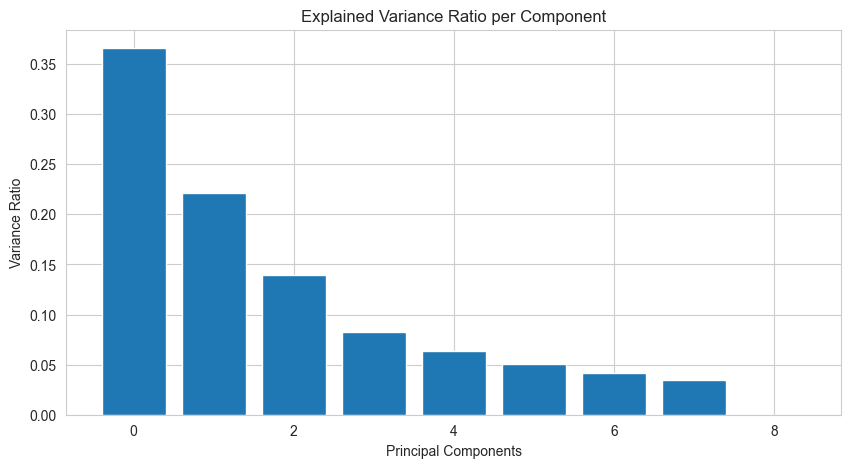

In [40]:
plt.figure(figsize=(10,5))
plt.bar(range(len(explained_variance)), explained_variance)
plt.title("Explained Variance Ratio per Component")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.show()

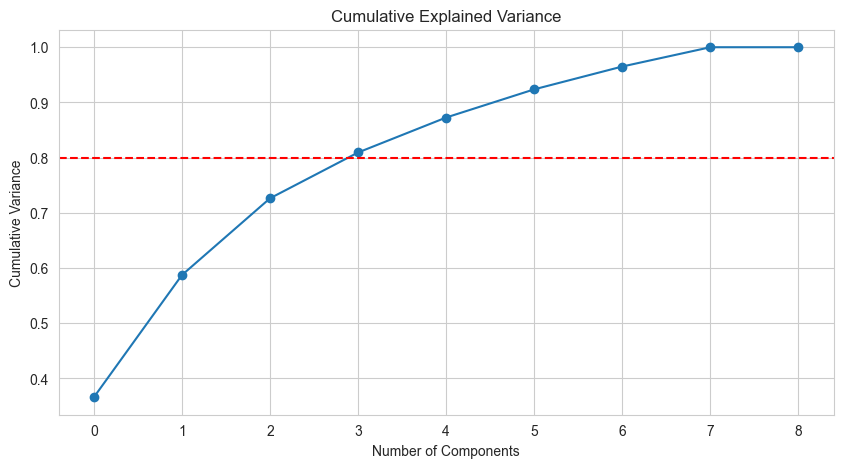

In [41]:
plt.figure(figsize=(10,5))
plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.8, color='r', linestyle='--')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

In [42]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

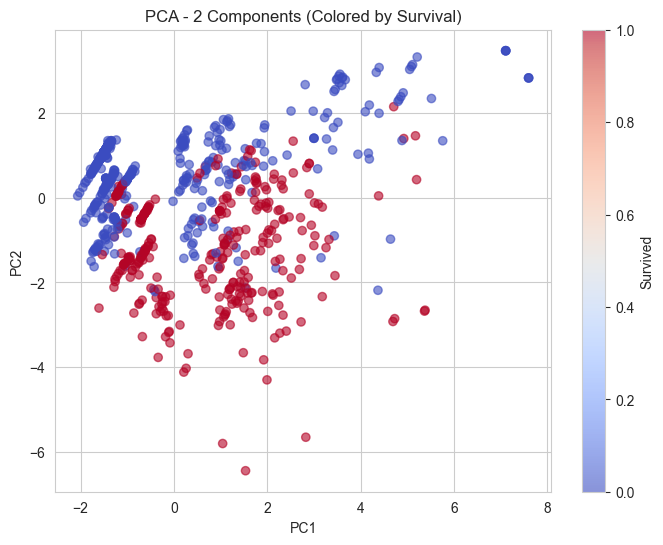

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["survived"],
    cmap="coolwarm",
    alpha=0.6
)

plt.title("PCA - 2 Components (Colored by Survival)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Survived")
plt.show()

### Markdown

From the PCA visualization, we can see that there is no clear and strong separation between the two classes (survived and not survived) in the 2D principal component space. The data points are still heavily mixed, which suggests that reducing the dataset to two dimensions does not preserve a clear class boundary.

This indicates that PCA does not significantly help in separating the target classes for this dataset. Instead, it mainly captures the directions of highest variance in the data, which are not necessarily aligned with the survival outcome.

Because of this, using PCA as a preprocessing step may not be very beneficial for this problem. The original feature space, especially after proper encoding and feature engineering, already contains meaningful information for prediction. Models like logistic regression, decision trees, or random forests can perform well without dimensionality reduction.

In conclusion, PCA is useful for visualization and understanding data structure, but for this dataset, the original features are sufficient for building a strong predictive model.